# Acceptance Rate of Fix-Type Pull Requests (AIDev Dataset)

This notebook calculates the acceptance (merge) rate of **fix-type** pull requests from the [AIDev dataset](https://huggingface.co/datasets/hao-li/AIDev).

## 1. Import Required Libraries

In [13]:
%pip install -q "pandas>=2.2" "pyarrow>=15.0" numpy matplotlib seaborn fsspec huggingface_hub jinja2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FONT_SCALE = 1.10
_BASE_FONT = 6.5

sns.set_style("whitegrid")
sns.set_context("talk", font_scale=FONT_SCALE)

plt.rcParams.update({
    'font.serif': ['Times New Roman', 'Times'],
    'mathtext.fontset': 'stix',
    'axes.linewidth': 1.0,
    'axes.labelsize': _BASE_FONT,
    'axes.titlesize': _BASE_FONT,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
    'xtick.labelsize': _BASE_FONT,
    'ytick.labelsize': _BASE_FONT,
    'legend.fontsize': _BASE_FONT,
    'legend.title_fontsize': _BASE_FONT,
    'axes.edgecolor': 'grey',
    'figure.dpi': 300,
})

Note: you may need to restart the kernel to use updated packages.


## 2. Download and Load the AIDev Parquet Files

In [14]:
urls = {
    "pull_request": "hf://datasets/hao-li/AIDev/pull_request.parquet",
    "pr_task_type": "hf://datasets/hao-li/AIDev/pr_task_type.parquet",
}

for name, url in urls.items():
    print(f"Downloading {name}...")
    df = None
    while df is None:
        try:
            df = pd.read_parquet(url)
        except Exception as e:
            if "429" in str(e):
                print("Rate limited. Retrying...")
                continue
            else:
                raise
    df.to_parquet(f"{name}.parquet")
    print(f"Saved {name}.parquet")

print("All files downloaded locally!")

Saved pull_request.parquet
Saved pr_task_type.parquet
All files downloaded locally!


In [15]:
pr_df = pd.read_parquet("pull_request.parquet")
pr_task_type_df = pd.read_parquet("pr_task_type.parquet")

print(f"pull_request shape: {pr_df.shape}")
print(f"pr_task_type shape: {pr_task_type_df.shape}")
print(f"\npull_request columns: {list(pr_df.columns)}")
print(f"pr_task_type columns: {list(pr_task_type_df.columns)}")

pull_request shape: (33596, 14)
pr_task_type shape: (33596, 6)

pull_request columns: ['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url', 'html_url']
pr_task_type columns: ['agent', 'id', 'title', 'reason', 'type', 'confidence']


## 3. Filter for Fix-Type Pull Requests

In [16]:
fix_prs = pr_task_type_df[pr_task_type_df['type'] == 'fix']
print(f"Total fix-type PRs: {len(fix_prs):,}")
print(f"\nTask type distribution:\n{pr_task_type_df['type'].value_counts()}")

Total fix-type PRs: 8,106

Task type distribution:
type
feat        14450
fix          8106
docs         3887
test         2356
refactor     2288
chore         896
build         627
ci            411
perf          340
style         188
other          31
revert         16
Name: count, dtype: int64


## 4. Merge Fix PRs with Pull Request Metadata

In [17]:
# Drop columns that exist in both DataFrames to avoid duplicates
fix_prs_clean = fix_prs.drop(columns=['title', 'agent'], errors='ignore')

# Merge fix PRs with PR metadata and keep only closed PRs
merged_df = pd.merge(pr_df, fix_prs_clean, on='id', how='inner')
merged_df = merged_df[merged_df['state'] == 'closed']

# Remove all OpenAI_Codex PRs (consistent with preprocessing notebook)
merged_df = merged_df[merged_df['agent'] != 'OpenAI_Codex']

print(f"Closed fix PRs (excl. Codex): {len(merged_df):,} rows")
print(f"\nAgent distribution:\n{merged_df['agent'].value_counts()}")

Closed fix PRs (excl. Codex): 3,225 rows

Agent distribution:
agent
Copilot        1558
Devin          1211
Cursor          365
Claude_Code      91
Name: count, dtype: int64


## 5. Classify PRs as Accepted or Rejected

Filter to only **closed** PRs and classify them based on the `merged_at` field.

In [18]:
# Classify: accepted (merged) vs rejected (closed but not merged)
merged_df['accepted'] = merged_df['merged_at'].notna()

print(f"Total closed fix PRs: {len(merged_df):,}")
print(f"Accepted (merged):    {merged_df['accepted'].sum():,}")
print(f"Rejected (not merged): {(~merged_df['accepted']).sum():,}")

Total closed fix PRs: 3,225
Accepted (merged):    1,728
Rejected (not merged): 1,497


## 6. Calculate Overall Acceptance Rate

In [19]:
total_closed = len(merged_df)
merged_count = merged_df['accepted'].sum()
rejected_count = total_closed - merged_count
acceptance_rate = (merged_count / total_closed) * 100

print("=" * 50)
print("OVERALL ACCEPTANCE RATE FOR FIX-TYPE PRs")
print("=" * 50)
print(f"Total closed fix PRs:  {total_closed:,}")
print(f"Merged (accepted):     {merged_count:,}")
print(f"Not merged (rejected): {rejected_count:,}")
print(f"Acceptance rate:       {acceptance_rate:.2f}%")
print("=" * 50)

OVERALL ACCEPTANCE RATE FOR FIX-TYPE PRs
Total closed fix PRs:  3,225
Merged (accepted):     1,728
Not merged (rejected): 1,497
Acceptance rate:       53.58%


## 7. Calculate Acceptance Rate by Agent

In [20]:
agent_stats = merged_df.groupby('agent').agg(
    total=('accepted', 'count'),
    merged=('accepted', 'sum')
).reset_index()

agent_stats['rejected'] = agent_stats['total'] - agent_stats['merged']
agent_stats['acceptance_rate'] = (agent_stats['merged'] / agent_stats['total']) * 100
agent_stats = agent_stats.sort_values('acceptance_rate', ascending=False).reset_index(drop=True)

agent_stats

,agent,total,merged,rejected,acceptance_rate
0,Cursor,365,281,84,76.986301
1,Claude_Code,91,66,25,72.527473
2,Copilot,1558,845,713,54.236200
3,Devin,1211,536,675,44.260941


## 8. Visualize Acceptance Rates by Agent

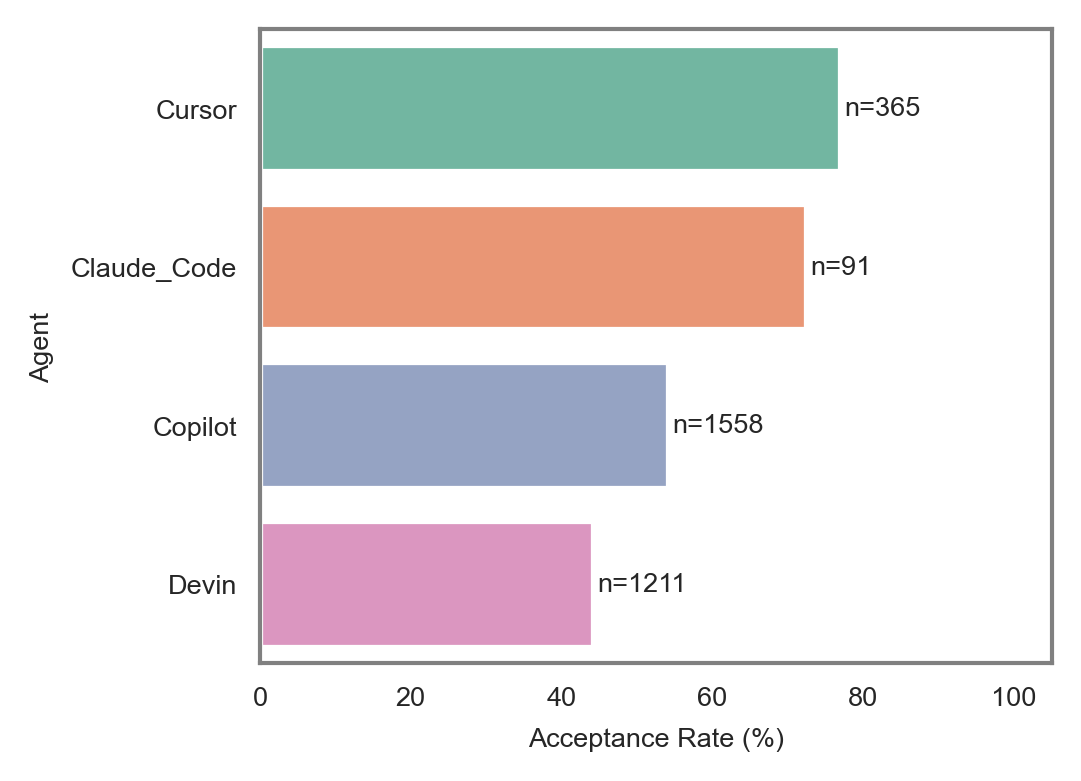

In [21]:
fig, ax = plt.subplots(figsize=(4, 3))

bars = sns.barplot(
    data=agent_stats,
    y='agent',
    x='acceptance_rate',
    palette='Set2',
    hue='agent',
    legend=False,
    ax=ax,
)

# Annotate bars with count
for i, row in agent_stats.iterrows():
    ax.text(
        row['acceptance_rate'] + 0.5,
        i,
        f"n={int(row['total'])}",
        va='center',
        fontsize=_BASE_FONT,
    )

ax.set_xlabel('Acceptance Rate (%)')
ax.set_ylabel('Agent')
ax.set_xlim(0, 105)
ax.grid(False)
fig.tight_layout()

plt.savefig('figs/acceptance_rate_by_agent.pdf', bbox_inches='tight', pad_inches=0.01, dpi=300)
plt.show()

## 9. Statistical Summary Table

In [22]:
summary = agent_stats[['agent', 'total', 'merged', 'rejected', 'acceptance_rate']].copy()
summary.columns = ['Agent', 'Total Fix PRs', 'Merged', 'Rejected', 'Acceptance Rate (\\%)']
summary['Acceptance Rate (\\%)'] = summary['Acceptance Rate (\\%)'].map(lambda x: f"{x:.2f}")

# Add overall row
summary.loc[len(summary)] = [
    '\\textbf{Overall}',
    total_closed,
    int(merged_count),
    int(rejected_count),
    f"{acceptance_rate:.2f}",
]

print(summary.to_string(index=False))

# Export as LaTeX
latex_table = summary.to_latex(
    index=False,
    caption='Acceptance Rate of Fix-Type Agentic Pull Requests by Agent',
    label='tab:acceptance_rate_fixes',
    position='!h',
    escape=False,
)
print("\n" + latex_table)

           Agent  Total Fix PRs  Merged  Rejected Acceptance Rate (\%)
          Cursor            365     281        84                76.99
     Claude_Code             91      66        25                72.53
         Copilot           1558     845       713                54.24
           Devin           1211     536       675                44.26
\textbf{Overall}           3225    1728      1497                53.58

\begin{table}[!h]
\caption{Acceptance Rate of Fix-Type Agentic Pull Requests by Agent}
\label{tab:acceptance_rate_fixes}
\begin{tabular}{lrrrl}
\toprule
Agent & Total Fix PRs & Merged & Rejected & Acceptance Rate (\%) \\
\midrule
Cursor & 365 & 281 & 84 & 76.99 \\
Claude_Code & 91 & 66 & 25 & 72.53 \\
Copilot & 1558 & 845 & 713 & 54.24 \\
Devin & 1211 & 536 & 675 & 44.26 \\
\textbf{Overall} & 3225 & 1728 & 1497 & 53.58 \\
\bottomrule
\end{tabular}
\end{table}

